In [2]:
# ================================================================
# STEP 1: Zaroori libraries import karna + CSV files load karna
# ================================================================

# pandas — data ko table (DataFrame) format mein load/manipulate
# karne ke liye. Yeh Python ka "Excel jaisa" tool hai, bas code se
# control hota hai
import pandas as pd

# numpy — numerical calculations ke liye (hum aage mein use karenge
# jab thoda math/stats karna hoga)
import numpy as np

# ----------------------------------------------------------------
# Ab saari CSV files ko load karte hain — har CSV ek alag
# DataFrame (jaise Excel ka alag sheet) ban jaayegi
# ----------------------------------------------------------------
customers = pd.read_csv(r"C:\Users\OS\Downloads\quality_customers_dataset\customers.csv")
orders = pd.read_csv(r"C:\Users\OS\Downloads\quality_customers_dataset\orders.csv")
order_items = pd.read_csv(r"C:\Users\OS\Downloads\quality_customers_dataset\order_items.csv")
products = pd.read_csv(r"C:\Users\OS\Downloads\quality_customers_dataset\products.csv")

# ----------------------------------------------------------------
# Verify karte hain ki sab sahi load hui — SQL ke COUNT(*) jaisa
# yeh check hai
# ----------------------------------------------------------------
print("customers shape:", customers.shape)     # (rows, columns)
print("orders shape:", orders.shape)
print("order_items shape:", order_items.shape)
print("products shape:", products.shape)

# .shape ek tuple deta hai (kitni rows, kitne columns) —
# expected: customers ~(2030, 6), orders ~(6020, 5) waise hi jaisa
# SQL mein COUNT(*) se dekha tha

customers shape: (2030, 6)
orders shape: (6020, 5)
order_items shape: (14921, 5)
products shape: (150, 4)


In [3]:
# ================================================================
# STEP 2: Data ko "eyeball" karna — jaisa koi naya Data Analyst
# join karke sabse pehle apne data ko dekhta hai
# ================================================================

# .head() top 5 rows dikhata hai — quick sense milta hai ki
# columns mein kaisa data hai (SQL ke "LIMIT 5" jaisa hi kaam)
print("=== CUSTOMERS PREVIEW ===")
print(customers.head())

print("\n=== ORDERS PREVIEW ===")
print(orders.head())

print("\n=== ORDER_ITEMS PREVIEW ===")
print(order_items.head())

# ----------------------------------------------------------------
# .info() — har column ka data type aur kitne non-null values hain
# yeh ek saath dikha deta hai. Real job mein yeh sabse pehla
# command hota hai jab naya dataset milta hai — "kya kaam karna
# padega" turant pata chal jaata hai
# ----------------------------------------------------------------
print("\n=== CUSTOMERS INFO (data types + nulls) ===")
customers.info()

print("\n=== ORDER_ITEMS INFO ===")
order_items.info()

=== CUSTOMERS PREVIEW ===
   customer_id         name             email       city signup_date  gender
0            1  Karan Verma               NaN  Bangalore  08-09-2023       M
1            2  Karan Yadav  karan2@gmail.com      delhi  2024/08/27       F
2            3   Sneha Iyer  sneha3@gmail.com       Pune  07/23/2023  Female
3            4   Sneha Nair  sneha4@gmail.com        NaN  09-06-2025       F
4            5  Divya Reddy  divya5@gmail.com     MUMBAI  2023/08/09       M

=== ORDERS PREVIEW ===
   order_id  customer_id   order_date order_status payment_method
0         1         1826   19/09/2023     Returned     Debit Card
1         2         1199  22-Jun-2023     Returned            COD
2         3          461   19/06/2024    DELIVERED            NaN
3         4         1966   2024-09-05    DELIVERED     Debit Card
4         5         1714   2024-12-19    DELIVERED            UPI

=== ORDER_ITEMS PREVIEW ===
   order_item_id  order_id  product_id  quantity   unit_price
0

In [4]:
# ================================================================
# STEP 3: CUSTOMERS table cleaning
# Business context: Marketing team accurate city/gender-wise
# report chahti hai — agar "Delhi" aur "delhi" alag maane gaye,
# report galat dikhegi (ek city do baar count hogi)
# ================================================================

# ---- 3A: Duplicate customer rows hatana ----
# Soch: SQL mein pata chala tha customer_id duplicate hai (30 extra
# rows). keep="first" — pehli occurrence rakho, baaki hata do
before = customers.shape[0]
customers = customers.drop_duplicates(subset="customer_id", keep="first")
after = customers.shape[0]
print(f"Duplicate rows removed: {before - after}")   # expect 30

# ---- 3B: City ko standardize karna ----
# .str.strip() — aage-peeche ka extra space hatata hai (agar ho)
# .str.title() — "delhi" -> "Delhi", "MUMBAI" -> "Mumbai" —
# sabko ek consistent "Title Case" mein la deta hai
customers["city"] = customers["city"].str.strip().str.title()

# ---- 3C: Gender ko standardize karna ----
# .replace() ek dictionary leta hai: "purani value": "nayi value"
# Business ko sirf "Male"/"Female" chahiye, short-form nahi
customers["gender"] = customers["gender"].replace({"M": "Male", "F": "Female"})

# ---- 3D: signup_date ko proper datetime banana ----
# Soch: humne dekha date 3 alag formats mein hai:
# "08-09-2023" (DD-MM-YYYY), "2024/08/27" (YYYY/MM/DD),
# "07/23/2023" (MM/DD/YYYY). Ek hi pd.to_datetime() teeno format
# nahi samajh sakta, isliye ek function banate hain jo teeno try kare
def parse_any_date(value):
    for fmt in ("%d-%m-%Y", "%Y/%m/%d", "%m/%d/%Y"):
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue   # is format mein nahi bana, agla try karo
    return pd.NaT   # koi format match nahi hua toh "missing date"

customers["signup_date"] = customers["signup_date"].apply(parse_any_date)

# ---- Verify: cleaning ke baad kaisa dikh raha hai ----
print(customers.head())
print("\nUnique cities after cleaning:", customers["city"].unique())
print("\nUnique genders after cleaning:", customers["gender"].unique())

Duplicate rows removed: 30
   customer_id         name             email       city signup_date  gender
0            1  Karan Verma               NaN  Bangalore  2023-09-08    Male
1            2  Karan Yadav  karan2@gmail.com      Delhi  2024-08-27  Female
2            3   Sneha Iyer  sneha3@gmail.com       Pune  2023-07-23  Female
3            4   Sneha Nair  sneha4@gmail.com        NaN  2025-06-09  Female
4            5  Divya Reddy  divya5@gmail.com     Mumbai  2023-08-09    Male

Unique cities after cleaning: ['Bangalore' 'Delhi' 'Pune' nan 'Mumbai' 'Bengaluru' 'Jaipur' 'Hyderabad'
 'Kolkata' 'Chennai']

Unique genders after cleaning: ['Male' 'Female' nan]


In [5]:
# ================================================================
# STEP 4: ORDERS table cleaning
# Business context: order_status ko clean karna zaroori hai warna
# "Delivered" revenue calculate karte time kuch rows chhoot jayengi
# (jaise "delivered" wali rows match nahi hongi agar hum sirf
# "Delivered" filter karte)
# ================================================================

# ---- 4A: Duplicate order_id hatana ----
before = orders.shape[0]
orders = orders.drop_duplicates(subset="order_id", keep="first")
after = orders.shape[0]
print(f"Duplicate orders removed: {before - after}")   # expect 20

# ---- 4B: order_status ko lowercase mein standardize karna ----
# .str.lower() sabko ek hi case mein le aata hai —
# "Delivered"/"DELIVERED"/"delivered" -> sab "delivered" ban jaayenge
orders["order_status"] = orders["order_status"].str.lower()

# ---- 4C: order_date ko proper datetime banana ----
# Soch: humne preview mein dekha 3 formats hain:
# "19/09/2023" (DD/MM/YYYY), "2024-09-05" (YYYY-MM-DD),
# "22-Jun-2023" (DD-Mon-YYYY) — same technique jo customers mein use ki
def parse_order_date(value):
    for fmt in ("%d/%m/%Y", "%Y-%m-%d", "%d-%b-%Y"):
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

orders["order_date"] = orders["order_date"].apply(parse_order_date)

# Jo rows date parse nahi hui (NaT ban gayi), unhe hata dete hain
# kyunki bina date ke RFM ka "Recency" calculate nahi ho sakta
before_drop = orders.shape[0]
orders = orders.dropna(subset=["order_date"])
print(f"Rows dropped due to unparseable date: {before_drop - orders.shape[0]}")

print("\nUnique order_status after cleaning:", orders["order_status"].unique())
print(orders.head())


# ================================================================
# STEP 5: ORDER_ITEMS table cleaning
# Business context: Total revenue calculate karne ke liye unit_price
# ek proper number hona chahiye, aur negative quantity fix honi
# chahiye — warna revenue ka number galat/kam aayega
# ================================================================

# ---- 5A: unit_price ko text se number banana ----
# Soch: kuch values "Rs.5,251.03" jaisi text mein hain (currency
# symbol + comma). Pehle .astype(str) se sabko text banaya
# (consistency ke liye), phir "Rs." aur "," hataya, phir number
# (float) mein convert kiya
order_items["unit_price"] = (
    order_items["unit_price"].astype(str)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# ---- 5B: Negative quantity fix karna ----
# Soch: SQL mein humne dekha tha MIN(quantity) = -5 tha — yeh
# data-entry error hai (koi customer -5 quantity order nahi kar
# sakta). .abs() se sign hata ke positive bana rahe hain
order_items["quantity"] = order_items["quantity"].abs()

# ---- 5C: Har line item ka total value nikalna ----
# Business logic: line_total = kitna price x kitni quantity
order_items["line_total"] = order_items["unit_price"] * order_items["quantity"]

print(order_items.head())
print("\nunit_price stats after cleaning:")
print(order_items["unit_price"].describe())

Duplicate orders removed: 20
Rows dropped due to unparseable date: 0

Unique order_status after cleaning: ['returned' 'delivered' 'pending' 'cancelled']
   order_id  customer_id order_date order_status payment_method
0         1         1826 2023-09-19     returned     Debit Card
1         2         1199 2023-06-22     returned            COD
2         3          461 2024-06-19    delivered            NaN
3         4         1966 2024-09-05    delivered     Debit Card
4         5         1714 2024-12-19    delivered            UPI
   order_item_id  order_id  product_id  quantity  unit_price  line_total
0              1         1          28         2     4788.68     9577.36
1              2         1          45         2     7558.34    15116.68
2              3         1         128         5     3957.43    19787.15
3              4         1         143         1     5215.74     5215.74
4              5         2          31         4     5251.03    21004.12

unit_price stats after c

In [6]:
# ================================================================
# STEP 6: RFM Base Table Banana
# Business context: Ab teeno cleaned tables ko jodkar har customer
# ke liye 3 numbers nikalne hain — Recency (kitne din pehle order
# kiya), Frequency (kitni baar order kiya), Monetary (kitna spend
# kiya). Yehi 3 numbers "quality customer" define karenge.
# ================================================================

# ---- 6A: Sirf DELIVERED orders lena ----
# Soch: Cancelled/Returned orders ko revenue mein nahi ginna chahiye
# — business logic hai ki jo customer ne actually rakha/receive
# kiya, sirf woh hi uski "value" count hoti hai
delivered = orders[orders["order_status"] == "delivered"]

# ---- 6B: orders ko order_items ke saath merge karna ----
# .merge() SQL ke JOIN jaisa hi kaam karta hai — common column
# (order_id) ke through do tables ko jodta hai
merged = delivered.merge(order_items, on="order_id")

# ---- 6C: Har ORDER ka total value nikalna ----
# Ek order mein multiple items ho sakte hain (jaise order_id=1 mein
# 4 items the) — pehle unhe jodkar ek order ka total banate hain
order_value = merged.groupby(
    ["order_id", "customer_id", "order_date"], as_index=False
)["line_total"].sum()

# ---- 6D: Snapshot date decide karna (Recency calculate karne ke liye) ----
# Soch: "Recency" ka matlab hai "aaj se kitne din pehle order kiya"
# — lekin humare paas "aaj" nahi hai (data purana hai), isliye
# hum dataset ki sabse latest date ke ek din baad ko "aaj" maan lete
# hain — yeh RFM analysis ka standard practice hai
snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)
print("Snapshot date (treated as 'today'):", snapshot_date)

# ---- 6E: Customer-level RFM table banana ----
# .agg() ek saath multiple calculations kar sakta hai, alag-alag
# columns pe, alag-alag function ke saath
rfm = order_value.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "count"),
    monetary=("line_total", "sum")
).reset_index()

print(rfm.head(10))
print("\nRFM shape:", rfm.shape)
print("\nRFM summary stats:")
print(rfm.describe())

Snapshot date (treated as 'today'): 2025-08-09 00:00:00
   customer_id  recency  frequency   monetary
0            2      657          1   47086.31
1            3      153          4   93346.89
2            4       20          1   38574.05
3            5      947          1   22302.44
4            6      284          4   78574.02
5            8      263          3   29494.11
6            9      833          2  164885.02
7           10       69          2   70987.73
8           13      561          1   95015.43
9           14      332          2   51460.96

RFM shape: (1579, 4)

RFM summary stats:
       customer_id      recency    frequency       monetary
count  1579.000000  1579.000000  1579.000000    1579.000000
mean   1005.912603   356.207726     1.912603   57299.910595
std     572.358990   259.168623     1.050662   41813.655348
min       2.000000     1.000000     1.000000     287.240000
25%     519.500000   134.500000     1.000000   26376.435000
50%    1002.000000   302.000000     

In [7]:
# ================================================================
# STEP 7: RFM Scoring — Raw numbers ko 1-5 score mein convert karna
# Business context: "Recency=657 days" ya "Monetary=47086" jaise
# raw numbers compare karna mushkil hai. Isliye har metric ko
# 1-5 ke score mein convert karte hain (5 = best), phir teeno
# scores jodkar ek "Quality Segment" banate hain
# ================================================================

# ---- 7A: Recency ko score dena ----
# pd.qcut() data ko 5 barabar hisso (quintiles) mein baant deta hai
# Soch: Recency mein KAM din = ACCHA (customer recently aaya tha)
# isliye labels ULTA diye — sabse kam recency ko score 5, sabse
# zyada recency ko score 1
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# ---- 7B: Frequency ko score dena ----
# Soch: Bahut saare customers ki frequency same hai (jaise sabki 1),
# isliye qcut seedha lagane pe "duplicate bin edges" error aata hai.
# .rank(method="first") se pehle sabko unique rank de dete hain,
# phir uspe qcut lagate hain
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)

# ---- 7C: Monetary ko score dena ----
# Soch: Zyada spend = zyada accha, isliye seedha order (1 se 5)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# ---- 7D: Teeno scores jodkar ek total banana ----
# Range: minimum 3 (1+1+1) se maximum 15 (5+5+5) tak
rfm["RFM_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# ---- 7E: Business-friendly segment label banana ----
# Soch: Business team ko "RFM_total=13" samajh nahi aayega, unhe
# seedha "High-Quality" jaisa label chahiye jo action lene mein
# madad kare (jaise marketing team High-Quality ko special offer de)
def segment(score):
    if score >= 12:
        return "High-Quality"
    elif score >= 8:
        return "Medium-Quality"
    else:
        return "Low-Quality"

rfm["quality_segment"] = rfm["RFM_total"].apply(segment)

# ---- Result dekhna ----
print("Segment distribution:")
print(rfm["quality_segment"].value_counts())

print("\nTop 10 High-Quality customers:")
print(
    rfm.sort_values("RFM_total", ascending=False)
    .head(10)[["customer_id", "recency", "frequency", "monetary", "RFM_total", "quality_segment"]]
)

Segment distribution:
quality_segment
Medium-Quality    588
Low-Quality       563
High-Quality      428
Name: count, dtype: int64

Top 10 High-Quality customers:
      customer_id  recency  frequency   monetary  RFM_total quality_segment
803          1018       47          3  135823.56         15    High-Quality
1372         1741      102          3  102998.63         15    High-Quality
1388         1761       97          4  168937.65         15    High-Quality
1181         1499       22          6  217928.20         15    High-Quality
276           366       44          4   98571.31         15    High-Quality
828          1050       70          3   99435.33         15    High-Quality
541           697       65          4  137122.06         15    High-Quality
284           377       25          4  118412.67         15    High-Quality
1002         1267      103          3   91513.90         15    High-Quality
1415         1792       29          7  259121.27         15    High-Quality


C:\Users\OS\AppData\Local\Temp\ipykernel_20228\3826394781.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


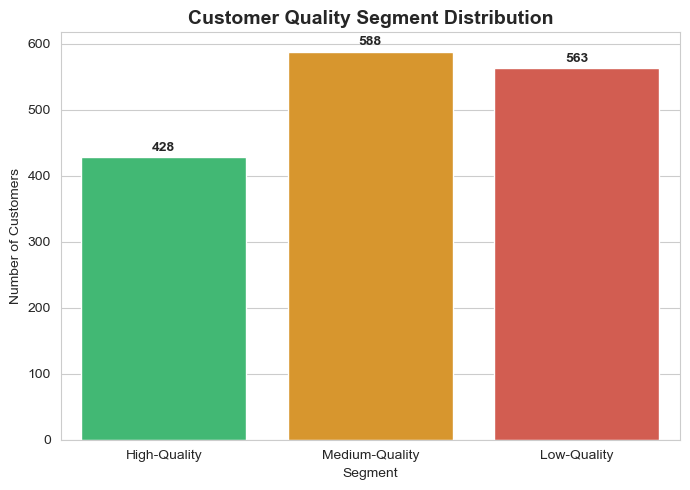

In [9]:
# ================================================================
# STEP 8: Visualization — RFM insights ko charts mein dikhana
# Business context: Numbers table mein dekhna technical logon ke
# liye theek hai, lekin management/stakeholders ko visual chahiye
# taaki 5 second mein insight samajh aa jaaye
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn ka ek clean theme set kar dete hain — professional
# dikhta hai, default matplotlib se better
sns.set_style("whitegrid")


# ----------------------------------------------------------------
# CHART 1: Segment Distribution (Bar Chart)
# Business question: "Kitne % customers kaunse segment mein hain?"

# ----------------------------------------------------------------
plt.figure(figsize=(7, 5))
segment_order = ["High-Quality", "Medium-Quality", "Low-Quality"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]   # green/orange/red — intuitive

sns.countplot(
    data=rfm, x="quality_segment", order=segment_order, palette=colors
)
plt.title("Customer Quality Segment Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

# Har bar ke upar exact count likhna — professional dashboards mein
# yeh common practice hai
for i, seg in enumerate(segment_order):
    count = (rfm["quality_segment"] == seg).sum()
    plt.text(i, count + 10, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("chart1_segment_distribution.png", dpi=150)
plt.show()

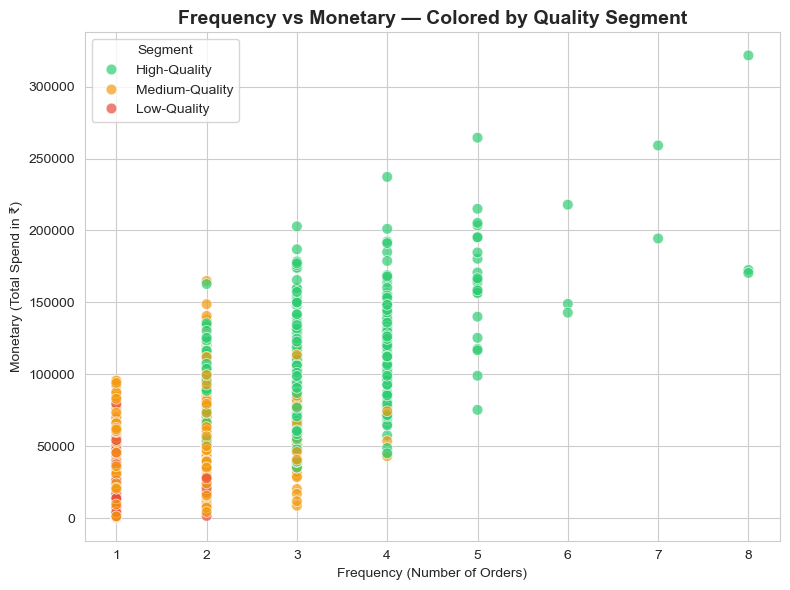

In [10]:
# ----------------------------------------------------------------
# CHART 2: Frequency vs Monetary Scatter (RFM ko visually explain)
# Business question: "High-Quality customers actually alag dikhte
# kaise hain baaki se?" — yeh chart RFM logic ko visually prove karta
# ----------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm, x="frequency", y="monetary",
    hue="quality_segment", hue_order=segment_order,
    palette=colors, alpha=0.7, s=60
)
plt.title("Frequency vs Monetary — Colored by Quality Segment", fontsize=14, fontweight="bold")
plt.xlabel("Frequency (Number of Orders)")
plt.ylabel("Monetary (Total Spend in ₹)")
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("chart2_frequency_vs_monetary.png", dpi=150)
plt.show()

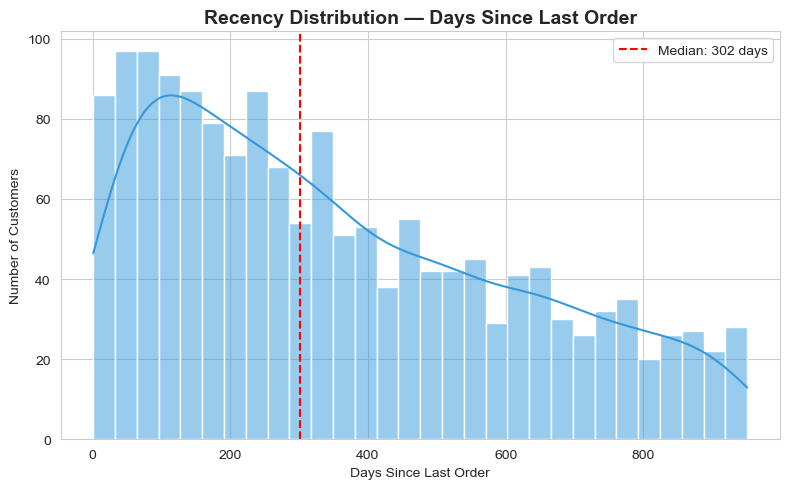

In [11]:
# ----------------------------------------------------------------
# CHART 3: Recency Distribution (Histogram)
# Business question: "Customers kitne active/inactive hain overall?"
# ----------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(rfm["recency"], bins=30, color="#3498db", kde=True)
plt.title("Recency Distribution — Days Since Last Order", fontsize=14, fontweight="bold")
plt.xlabel("Days Since Last Order")
plt.ylabel("Number of Customers")
plt.axvline(rfm["recency"].median(), color="red", linestyle="--", label=f"Median: {rfm['recency'].median():.0f} days")
plt.legend()
plt.tight_layout()
plt.savefig("chart3_recency_distribution.png", dpi=150)
plt.show()

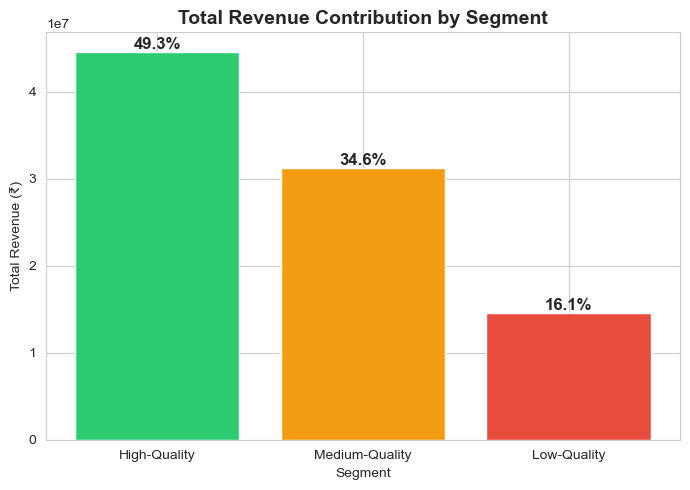

Revenue % by segment:
quality_segment
High-Quality      49.3
Medium-Quality    34.6
Low-Quality       16.1
Name: monetary, dtype: float64


In [12]:
# ----------------------------------------------------------------
# CHART 4: Total Revenue Contribution by Segment (Business Impact)
# Business question: "Sabse important — High-Quality customers
# COMPANY KA KITNA REVENUE laate hain?" Yeh hi asli business case hai
# ----------------------------------------------------------------
revenue_by_segment = rfm.groupby("quality_segment")["monetary"].sum().reindex(segment_order)
pct_of_total = (revenue_by_segment / revenue_by_segment.sum() * 100).round(1)

plt.figure(figsize=(7, 5))
bars = plt.bar(segment_order, revenue_by_segment.values, color=colors)
plt.title("Total Revenue Contribution by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Total Revenue (₹)")

# Har bar ke upar % likhna — yeh number sabse zyada "wow" karega
for bar, pct in zip(bars, pct_of_total):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f"{pct}%", ha="center", va="bottom", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("chart4_revenue_by_segment.png", dpi=150)
plt.show()

print("Revenue % by segment:")
print(pct_of_total)

In [13]:
# ================================================================
# STEP 9: ML Model — "Yeh Customer High-Quality Banega Ya Nahi?"
# Business context: Marketing team ke paas limited budget hai —
# sabko special treatment nahi de sakte. Agar model bata de ki
# kaunsa customer future mein High-Quality banega, toh unhi pe
# early focus/investment kiya ja sakta hai
# ================================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---- 9A: Target variable banana ----
# Soch: Model ko ek "haan/na" (binary) sawaal ka jawab dena hai —
# "High-Quality hai ya nahi" — isliye 1/0 mein convert kar rahe hain
rfm["is_high_quality"] = (rfm["quality_segment"] == "High-Quality").astype(int)

# ---- 9B: Features (X) aur Target (y) define karna ----
# X = jo cheezein model ko dekh kar predict karna hai (input)
# y = jo predict karna hai (output)
X = rfm[["recency", "frequency", "monetary"]]
y = rfm["is_high_quality"]

# ---- 9C: Train/Test Split ----
# Soch: Model ko saara data dekha ke test nahi kar sakte (woh toh
# "rata" maar lega). Isliye 80% data se seekhata hai (train), aur
# 20% "unseen" data pe test karta hai — jaisa real duniya mein hoga
# stratify=y — zaroori hai kyunki High-Quality customers minority
# hain (~27%); stratify dono train aur test mein same % maintain
# karta hai, warna test set mein accidentally sab Low-Quality aa
# sakte the
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- 9D: Feature Scaling ----
# Soch: recency (jaise 657) aur frequency (jaise 4) ka scale bahut
# alag hai — bina scaling ke, model "monetary" ko zyada important
# maan lega sirf isliye kyunki uske numbers bade hain. StandardScaler
# sabko ek comparable range mein le aata hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- 9E: Model Train Karna ----
# Logistic Regression — binary classification (haan/na) ke liye
# sabse simple aur explainable model, business ko samjhana bhi easy
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# ---- 9F: Predictions aur Evaluation ----
predictions = model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, predictions), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=["Not High-Quality", "High-Quality"]))

# ---- 9G: Feature Importance dekhna ----
# Soch: Business poochegi "kaunsi cheez sabse zyada matter karti
# hai High-Quality banne mein?" — coefficients yeh batate hain
print("\nFeature impact on prediction:")
for feature, coef in zip(X.columns, model.coef_[0]):
    direction = "increases" if coef > 0 else "decreases"
    print(f"{feature}: {round(coef, 3)} ({direction} chance of High-Quality)")

Accuracy: 0.9462

Confusion Matrix:
[[225   5]
 [ 12  74]]

Classification Report:
                  precision    recall  f1-score   support

Not High-Quality       0.95      0.98      0.96       230
    High-Quality       0.94      0.86      0.90        86

        accuracy                           0.95       316
       macro avg       0.94      0.92      0.93       316
    weighted avg       0.95      0.95      0.95       316


Feature impact on prediction:
recency: -3.982 (decreases chance of High-Quality)
frequency: 2.782 (increases chance of High-Quality)
monetary: 3.251 (increases chance of High-Quality)


In [17]:
# Option 1: r"" (raw string) lagao — backslash ko normal treat karega
rfm.to_csv(r"C:\Users\OS\Downloads\Final_cus_quality_scores.csv", index=False)